# QNN 生成模型 vs 经典 ML：Bars-and-Stripes 基准

本 notebook 在量子生成模型的经典基准 **Bars-and-Stripes (BAS)** 数据集上对比：
- **QNN 量子生成模型**（`run_qnn_unsupervised`，autograd NLL 损失）
- **RBM**（PyTorch 受限玻尔兹曼机，PCD 训练）
- **MADE**（Masked Autoencoder for Distribution Estimation，自回归生成模型）

**Bars-and-Stripes** 是量子生成模型最广泛使用的基准之一（Benedetti et al., 2019; Liu & Wang, 2018）：  
在 $m \times n$ 网格上，仅由全行相同（bars）或全列相同（stripes）构成的二值图案为有效样本。  
本教程使用 **4×4 网格**（16 量子比特），共 $2^{16}=65536$ 种比特串中有 **30 种有效图案**。

> 量子生成模型使用 hardware-efficient ansatz，通过 torch autograd + NLL 损失在模拟器上训练。  
> 若系统有 CUDA GPU，量子模拟将自动在 GPU 上运行。

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# GPU 检查
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from quantum_hw.sim.common import auto_sim_device
print(f"Simulation device: {auto_sim_device()}")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA RTX PRO 3000 Blackwell Generation Laptop GPU
Simulation device: cuda


## 1) Bars-and-Stripes 数据集

**4×4 网格** 的像素排列为（行优先展平为 16 qubit）：

```
q0  q1  q2  q3
q4  q5  q6  q7
q8  q9  q10 q11
q12 q13 q14 q15
```

有效图案分两类：
- **Bars**（横条纹）：每行像素相同 → $2^4 = 16$ 种
- **Stripes**（纵条纹）：每列像素相同 → $2^4 = 16$ 种

去重后（全 0 和全 1 重叠）共 **30 种有效图案**（均匀分布概率各 $1/30 \approx 3.3\%$）。

In [18]:
def generate_bas(rows, cols):
    """Generate all valid Bars-and-Stripes patterns on a rows×cols grid."""
    # Bars: each row uniform; row r's value determined by bit r of index
    r_bits = (np.arange(2**rows)[:, None] >> np.arange(rows)) & 1   # (2^rows, rows)
    bars = np.repeat(r_bits, cols, axis=1)                           # (2^rows, rows*cols)
    # Stripes: each col uniform; col c's value determined by bit c of index
    c_bits = (np.arange(2**cols)[:, None] >> np.arange(cols)) & 1   # (2^cols, cols)
    stripes = np.tile(c_bits, (1, rows))                             # (2^cols, rows*cols)
    return np.unique(np.vstack([bars, stripes]), axis=0).astype(np.int64)

ROWS, COLS = 4, 4
bas_patterns = generate_bas(ROWS, COLS)
num_qubits = ROWS * COLS
n_patterns = len(bas_patterns)

print(f"Valid BAS patterns: {n_patterns} / {2**num_qubits}")
print(f"Grid: {ROWS}×{COLS} = {num_qubits} qubits")
print(f"\nTarget probability per pattern: {1/n_patterns:.4f}")

Valid BAS patterns: 30 / 65536
Grid: 4×4 = 16 qubits

Target probability per pattern: 0.0333


In [19]:
# 从均匀 BAS 分布中采样训练/测试数据
rng = np.random.default_rng(42)

n_train = 5000
n_test = 1000

def sample_bas(n, rng):
    indices = rng.choice(n_patterns, size=n)
    return bas_patterns[indices]

train_samples = sample_bas(n_train, rng)
test_samples = sample_bas(n_test, rng)

# 统计训练集频率
target_prob = 1.0 / n_patterns
unique, counts = np.unique(train_samples, axis=0, return_counts=True)
print(f"Training samples: {n_train}")
print(f"Test samples:     {n_test}")
print(f"\nTraining distribution (all {len(unique)} unique patterns):")
for row, cnt in sorted(zip(unique.tolist(), counts.tolist()), key=lambda x: -x[1])[:10]:
    bs = ''.join(str(b) for b in row)
    print(f"  |{bs}⟩ : {cnt}/{n_train} = {cnt/n_train:.1%}  (target: {target_prob:.1%})")
print(f"  ... (showing top 10 of {len(unique)} patterns)")

Training samples: 5000
Test samples:     1000

Training distribution (all 30 unique patterns):
  |1111000000000000⟩ : 202/5000 = 4.0%  (target: 3.3%)
  |0110011001100110⟩ : 189/5000 = 3.8%  (target: 3.3%)
  |1111000011111111⟩ : 188/5000 = 3.8%  (target: 3.3%)
  |1000100010001000⟩ : 187/5000 = 3.7%  (target: 3.3%)
  |0000000011111111⟩ : 186/5000 = 3.7%  (target: 3.3%)
  |1111111111111111⟩ : 181/5000 = 3.6%  (target: 3.3%)
  |0000111100001111⟩ : 179/5000 = 3.6%  (target: 3.3%)
  |0000111100000000⟩ : 178/5000 = 3.6%  (target: 3.3%)
  |0010001000100010⟩ : 178/5000 = 3.6%  (target: 3.3%)
  |1111111100001111⟩ : 175/5000 = 3.5%  (target: 3.3%)
  ... (showing top 10 of 30 patterns)


## 2) BAS 图案可视化

将 30 种有效图案以 4×4 网格形式展示。

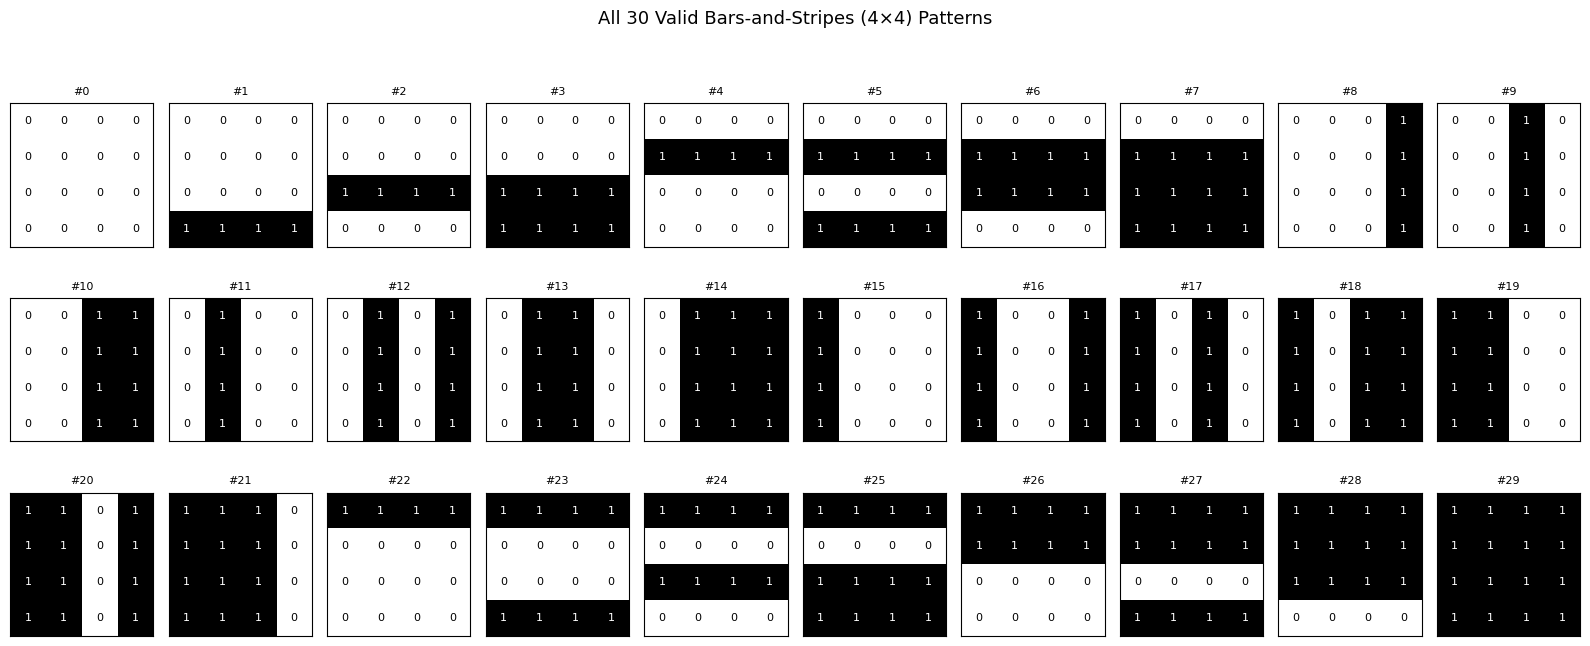

In [20]:
ncols_fig = 10
nrows_fig = (n_patterns + ncols_fig - 1) // ncols_fig

fig, axes = plt.subplots(nrows_fig, ncols_fig, figsize=(16, 2.2 * nrows_fig))
axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat):
    if idx < n_patterns:
        pattern = bas_patterns[idx]
        grid = pattern.reshape(ROWS, COLS)
        ax.imshow(grid, cmap='gray_r', vmin=0, vmax=1)
        ax.set_title(f"#{idx}", fontsize=8)
        for r in range(ROWS):
            for c in range(COLS):
                ax.text(c, r, str(grid[r, c]), ha='center', va='center',
                        fontsize=8, color='white' if grid[r, c] == 1 else 'black')
    else:
        ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'All {n_patterns} Valid Bars-and-Stripes ({ROWS}×{COLS}) Patterns', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3) 经典方法 Baseline

### 3a) RBM（PyTorch，PCD 训练）
使用 PyTorch 从零实现受限玻尔兹曼机。采用 **Persistent Contrastive Divergence (PCD)**
+ 多步 Gibbs 采样（CD-k, k=10），比 sklearn 的 CD-1 收敛质量高很多。

### 3b) MADE（Masked Autoencoder for Distribution Estimation）
**自回归生成模型**（Germain et al., 2015）。与 GPT/Transformer 本质相同，  
将联合概率建模为条件概率之积：$P(\mathbf{x}) = \prod_d P(x_d | \mathbf{x}_{<d})$。  
通过 **掩码全连接层** 在单次前向传播中计算所有条件概率，训练使用标准 BCE 损失 + Adam。

In [21]:
# ---- 3a) RBM (PyTorch, PCD-10) ----

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RBM(torch.nn.Module):
    """Bernoulli RBM trained with Persistent Contrastive Divergence."""

    def __init__(self, n_visible, n_hidden, n_chains=64):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(n_visible, n_hidden) * 0.01)
        self.vb = torch.nn.Parameter(torch.zeros(n_visible))
        self.hb = torch.nn.Parameter(torch.zeros(n_hidden))
        self.register_buffer('chains', torch.bernoulli(torch.full((n_chains, n_visible), 0.5)))

    def _h_prob(self, v):
        return torch.sigmoid(v @ self.W + self.hb)

    def _v_prob(self, h):
        return torch.sigmoid(h @ self.W.t() + self.vb)

    def _gibbs_step(self, v):
        h = torch.bernoulli(self._h_prob(v))
        return torch.bernoulli(self._v_prob(h))

    def free_energy(self, v):
        """F(v) = -v·vb - Σ_j log(1 + exp(v·W_j + hb_j))"""
        return -v @ self.vb - torch.sum(
            torch.nn.functional.softplus(v @ self.W + self.hb), dim=1)

    def pcd_step(self, v_data, cd_k=10, lr=0.01, weight_decay=1e-4):
        with torch.no_grad():
            pos_h = self._h_prob(v_data)
            v_neg = self.chains.clone()
            for _ in range(cd_k):
                v_neg = self._gibbs_step(v_neg)
            self.chains.copy_(v_neg)
            neg_h = self._h_prob(v_neg)
            dW = (v_data.t() @ pos_h) / len(v_data) - (v_neg.t() @ neg_h) / len(v_neg)
            dvb = v_data.mean(0) - v_neg.mean(0)
            dhb = pos_h.mean(0) - neg_h.mean(0)
            self.W.add_(lr * (dW - weight_decay * self.W))
            self.vb.add_(lr * dvb)
            self.hb.add_(lr * dhb)

    def fit(self, data, epochs=300, batch_size=64, cd_k=10, lr=0.05,
            weight_decay=1e-4, verbose=True):
        v_all = torch.as_tensor(data, dtype=torch.float32, device=self.W.device)
        n = len(v_all)
        for epoch in range(1, epochs + 1):
            perm = torch.randperm(n, device=v_all.device)
            for i in range(0, n, batch_size):
                self.pcd_step(v_all[perm[i:i+batch_size]], cd_k=cd_k,
                              lr=lr, weight_decay=weight_decay)
            if verbose and epoch % 100 == 0:
                fe = self.free_energy(v_all).mean().item()
                print(f"  epoch {epoch:>4d}  mean free energy = {fe:.4f}")

    @torch.no_grad()
    def probabilities(self, all_configs):
        v = torch.as_tensor(all_configs, dtype=torch.float32, device=self.W.device)
        neg_fe = -self.free_energy(v)
        neg_fe -= neg_fe.max()
        p = torch.exp(neg_fe)
        return (p / p.sum()).cpu().numpy()


# --- 训练 RBM ---
n_hidden = max(16, num_qubits * 4)
torch.manual_seed(42)
rbm_model = RBM(n_visible=num_qubits, n_hidden=n_hidden, n_chains=256).to(device)

print(f"RBM: {num_qubits} visible × {n_hidden} hidden, PCD-10, device={device}")
rbm_model.fit(train_samples, epochs=500, batch_size=64, cd_k=10, lr=0.05,
              weight_decay=1e-4, verbose=True)

# 枚举所有状态 → 精确概率
all_configs = np.array([[int(b) for b in format(i, f'0{num_qubits}b')]
                        for i in range(2**num_qubits)], dtype=np.float64)
rbm_probs = rbm_model.probabilities(all_configs)

dist_rbm = {format(i, f'0{num_qubits}b'): float(rbm_probs[i])
             for i in range(2**num_qubits)}

bas_labels = set(''.join(str(b) for b in row) for row in bas_patterns)
rbm_bas_mass = sum(dist_rbm[l] for l in bas_labels)
print(f"\nRBM probability on valid BAS: {rbm_bas_mass:.2%}")

rbm_on_bas = sorted([(l, dist_rbm[l]) for l in bas_labels], key=lambda x: -x[1])
print(f"\nRBM top-10 BAS patterns:")
for bs, p in rbm_on_bas[:10]:
    print(f"  |{bs}⟩ : {p:.4f}  (target: {target_prob:.4f})")

RBM: 16 visible × 64 hidden, PCD-10, device=cuda
  epoch  100  mean free energy = -84.7280
  epoch  200  mean free energy = -88.9706
  epoch  300  mean free energy = -92.0904
  epoch  400  mean free energy = -94.0018
  epoch  500  mean free energy = -97.1615

RBM probability on valid BAS: 98.93%

RBM top-10 BAS patterns:
  |1111000011111111⟩ : 0.4647  (target: 0.0333)
  |0000111111111111⟩ : 0.1472  (target: 0.0333)
  |0000111111110000⟩ : 0.1200  (target: 0.0333)
  |1111111111111111⟩ : 0.0701  (target: 0.0333)
  |0000111100001111⟩ : 0.0306  (target: 0.0333)
  |1001100110011001⟩ : 0.0227  (target: 0.0333)
  |1111000000001111⟩ : 0.0219  (target: 0.0333)
  |1111000011110000⟩ : 0.0211  (target: 0.0333)
  |1011101110111011⟩ : 0.0144  (target: 0.0333)
  |0000111100000000⟩ : 0.0140  (target: 0.0333)


In [22]:
# ---- 3b) MADE (Masked Autoencoder for Distribution Estimation) ----

class MaskedLinear(torch.nn.Module):
    """Linear layer with a fixed binary mask on weights."""
    def __init__(self, in_features, out_features, mask):
        super().__init__()
        self.linear = torch.nn.Linear(in_features, out_features)
        self.register_buffer('mask', mask)

    def forward(self, x):
        return torch.nn.functional.linear(x, self.linear.weight * self.mask, self.linear.bias)


class MADE(torch.nn.Module):
    """Masked Autoencoder for Distribution Estimation (Germain et al., 2015).

    自回归生成模型：P(x) = ∏_d P(x_d | x_{<d})。
    通过掩码权重矩阵在单次前向传播中计算所有条件概率。
    """
    def __init__(self, n_visible, hidden_sizes=(256, 256), seed=0):
        super().__init__()
        self.n_visible = n_visible
        rng_m = np.random.RandomState(seed)

        # 为每层分配 "degree"：输入/输出层 = 0..D-1
        m = [np.arange(n_visible)]
        for hs in hidden_sizes:
            m.append(np.sort(rng_m.randint(0, n_visible - 1, size=hs)))

        # 构建掩码层
        sizes = [n_visible] + list(hidden_sizes) + [n_visible]
        layers = []
        all_m = m + [np.arange(n_visible)]  # output ordering = input ordering

        for i in range(len(sizes) - 1):
            if i < len(sizes) - 2:
                # 隐层：允许 m_out >= m_in
                mask = torch.from_numpy(
                    (all_m[i+1][:, None] >= all_m[i][None, :]).astype(np.float32))
            else:
                # 输出层：严格 m_out > m_in（保证自回归）
                mask = torch.from_numpy(
                    (all_m[i+1][:, None] > all_m[i][None, :]).astype(np.float32))
            layers.append(MaskedLinear(sizes[i], sizes[i+1], mask))
            if i < len(sizes) - 2:
                layers.append(torch.nn.ReLU())

        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        """返回每个 visible unit 的 logit。"""
        return self.net(x)

    def log_prob(self, x):
        """log P(x) = Σ_d log P(x_d | x_{<d})"""
        logits = self.forward(x)
        return -torch.nn.functional.binary_cross_entropy_with_logits(
            logits, x, reduction='none').sum(-1)


# --- 训练 MADE ---
torch.manual_seed(42)
made_model = MADE(num_qubits, hidden_sizes=(256, 256), seed=0).to(device)
optimizer = torch.optim.Adam(made_model.parameters(), lr=1e-3)
train_tensor = torch.tensor(train_samples, dtype=torch.float32, device=device)

print(f"MADE: {num_qubits} inputs, hidden=[256, 256], autoregressive, device={device}")
for epoch in range(1, 801):
    perm = torch.randperm(len(train_tensor), device=device)
    epoch_loss = 0.0
    n_batch = 0
    for i in range(0, len(train_tensor), 64):
        batch = train_tensor[perm[i:i+64]]
        loss = -made_model.log_prob(batch).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batch += 1
    if epoch % 200 == 0:
        avg_loss = epoch_loss / n_batch
        print(f"  epoch {epoch:>4d}  mean NLL = {avg_loss:.4f}")

# 枚举所有状态 → 精确概率
with torch.no_grad():
    all_v = torch.tensor(all_configs, dtype=torch.float32, device=device)
    log_probs = made_model.log_prob(all_v)
    made_probs = torch.exp(log_probs)
    made_probs /= made_probs.sum()

dist_made = {format(i, f'0{num_qubits}b'): float(made_probs[i].cpu())
              for i in range(2**num_qubits)}

made_bas_mass = sum(dist_made[l] for l in bas_labels)
print(f"\nMADE probability on valid BAS: {made_bas_mass:.2%}")

made_on_bas = sorted([(l, dist_made[l]) for l in bas_labels], key=lambda x: -x[1])
print(f"\nMADE top-10 BAS patterns:")
for bs, p in made_on_bas[:10]:
    print(f"  |{bs}⟩ : {p:.4f}  (target: {target_prob:.4f})")

MADE: 16 inputs, hidden=[256, 256], autoregressive, device=cuda
  epoch  200  mean NLL = 3.4063
  epoch  400  mean NLL = 3.4005
  epoch  600  mean NLL = 3.3992
  epoch  800  mean NLL = 3.3994

MADE probability on valid BAS: 100.00%

MADE top-10 BAS patterns:
  |1111000000000000⟩ : 0.0399  (target: 0.0333)
  |0110011001100110⟩ : 0.0378  (target: 0.0333)
  |1111000011111111⟩ : 0.0375  (target: 0.0333)
  |1111111111111111⟩ : 0.0373  (target: 0.0333)
  |1000100010001000⟩ : 0.0367  (target: 0.0333)
  |0000000011111111⟩ : 0.0364  (target: 0.0333)
  |0010001000100010⟩ : 0.0363  (target: 0.0333)
  |0000111100000000⟩ : 0.0355  (target: 0.0333)
  |0000111100001111⟩ : 0.0352  (target: 0.0333)
  |1111111100001111⟩ : 0.0352  (target: 0.0333)


## 4) QNN 量子生成模型训练

使用 16 量子比特的 hardware-efficient ansatz，通过 autograd 最小化 NLL 损失：

$$\mathcal{L}_{\text{NLL}}(\theta) = -\sum_b w_b \log P(b|\theta)$$

其中 $w_b$ 是去重后各样本的频率权重。训练参数：
- `layers=4`：ansatz 深度
- `max_iters=200`：充分训练
- `learning_rate=0.01`：Adam 学习率

> 16 qubit 状态向量大小为 $2^{16}=65536$，单次前向/反向传播仍可在 GPU 上高效完成。

In [23]:
from quantum_hw.algorithms.qml import run_qnn_unsupervised

result_qnn = run_qnn_unsupervised(
    num_qubits=num_qubits,
    train_samples=train_samples,
    test_samples=test_samples,
    layers=6,
    max_iters=200,
    learning_rate=0.05,
    seed=42,
    gradient_method="autograd",
    gen_shots=8192,
)

print(f"\nBest loss (NLL): {result_qnn.best_loss:.6f}")
print(f"Parameters:      {len(result_qnn.best_params)}")
print(f"Generated:       {len(result_qnn.generated_samples)} samples")

[qnn-unsupervised] start: 16q, 224 params, 5000 train samples (30 unique), 200 iters, gradient=autograd, loss=NLL
[qnn-unsupervised] iter 0 loss=11.289772 test_loss=10.491097
[qnn-unsupervised] iter 20 loss=7.966029 test_loss=8.013748
[qnn-unsupervised] iter 40 loss=7.219651 test_loss=7.271815
[qnn-unsupervised] iter 60 loss=6.895105 test_loss=6.960415
[qnn-unsupervised] iter 80 loss=6.582703 test_loss=6.647814
[qnn-unsupervised] iter 100 loss=6.362231 test_loss=6.431007
[qnn-unsupervised] iter 120 loss=6.219258 test_loss=6.289892
[qnn-unsupervised] iter 140 loss=6.079905 test_loss=6.126561
[qnn-unsupervised] iter 160 loss=5.978355 test_loss=6.042090
[qnn-unsupervised] iter 180 loss=5.960997 test_loss=6.025426
[qnn-unsupervised] done. best_loss=6.006409, generated 8192 samples

Best loss (NLL): 6.006409
Parameters:      224
Generated:       8192 samples


## 5) 分布对比

柱状图对比目标均匀分布、RBM、MADE 和 QNN 在 **30 种有效 BAS 图案** 上的概率。

> 由于 $2^{16}=65536$ 种状态无法全部显示，仅展示 30 种有效图案的概率 + Non-BAS 泄漏。

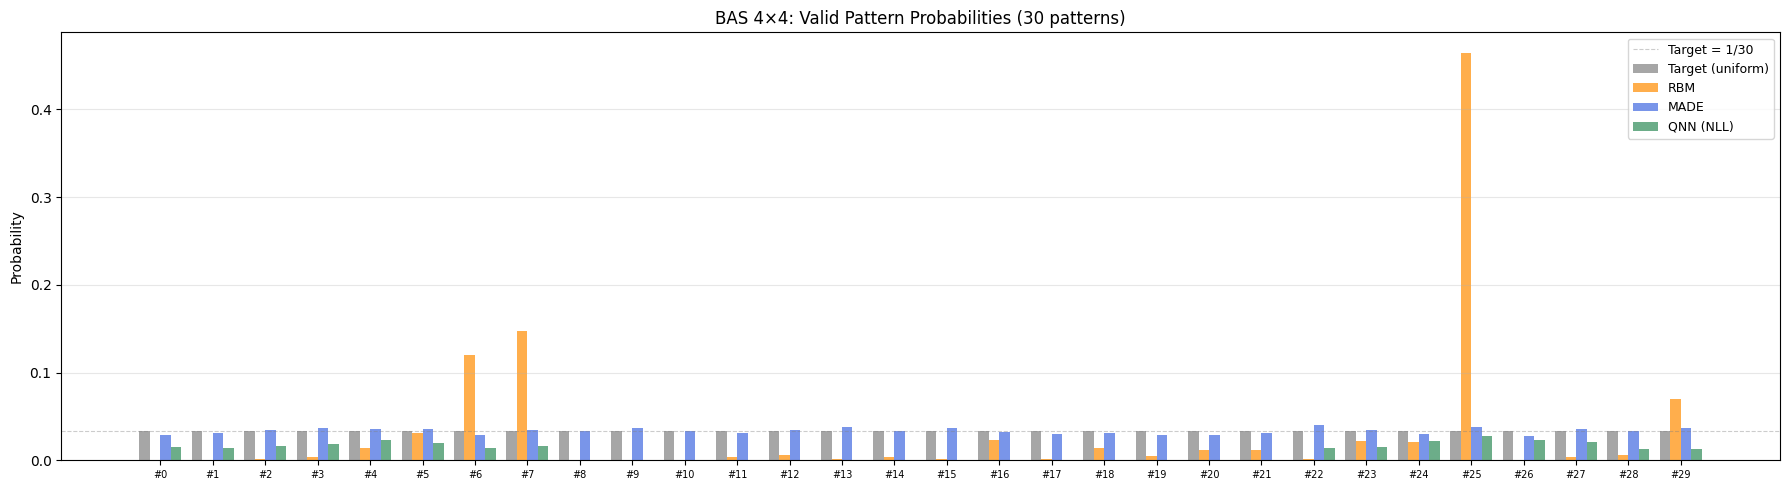

     RBM: BAS mass = 98.93%, non-BAS leakage = 1.07%
    MADE: BAS mass = 100.00%, non-BAS leakage = 0.00%
     QNN: BAS mass = 28.61%, non-BAS leakage = 71.39%


In [30]:
def count_distribution(samples, num_qubits):
    """Count frequency of each bitstring in samples."""
    samples = np.asarray(samples, dtype=int)
    freq = {}
    for row in samples:
        key = ''.join(str(b) for b in row)
        freq[key] = freq.get(key, 0) + 1
    total = len(samples)
    dist = {format(i, f'0{num_qubits}b'): 0.0 for i in range(2**num_qubits)}
    for k, v in freq.items():
        dist[k] = v / total
    return dist

dist_qnn = count_distribution(result_qnn.generated_samples, num_qubits)

# 目标分布
dist_target = {format(i, f'0{num_qubits}b'): 0.0 for i in range(2**num_qubits)}
for p in bas_patterns:
    dist_target[''.join(str(b) for b in p)] = target_prob

# 仅展示 30 种有效 BAS 图案
bas_label_list = sorted(bas_labels)
x = np.arange(len(bas_label_list))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - 1.5*width, [dist_target[l] for l in bas_label_list], width,
       label='Target (uniform)', color='gray', alpha=0.7)
ax.bar(x - 0.5*width, [dist_rbm[l] for l in bas_label_list], width,
       label='RBM', color='darkorange', alpha=0.7)
ax.bar(x + 0.5*width, [dist_made[l] for l in bas_label_list], width,
       label='MADE', color='royalblue', alpha=0.7)
ax.bar(x + 1.5*width, [dist_qnn[l] for l in bas_label_list], width,
       label='QNN (NLL)', color='seagreen', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"#{i}" for i in range(len(bas_label_list))], fontsize=7)
ax.set_ylabel('Probability')
ax.set_title(f'BAS {ROWS}×{COLS}: Valid Pattern Probabilities ({n_patterns} patterns)')
ax.axhline(y=target_prob, ls='--', color='gray', alpha=0.4, lw=0.8,
           label=f'Target = 1/{n_patterns}')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Non-BAS leakage summary
for name, dist in [("RBM", dist_rbm), ("MADE", dist_made), ("QNN", dist_qnn)]:
    bas_mass = sum(dist[l] for l in bas_labels)
    print(f"{name:>8}: BAS mass = {bas_mass:.2%}, non-BAS leakage = {1-bas_mass:.2%}")

## 6) 收敛曲线

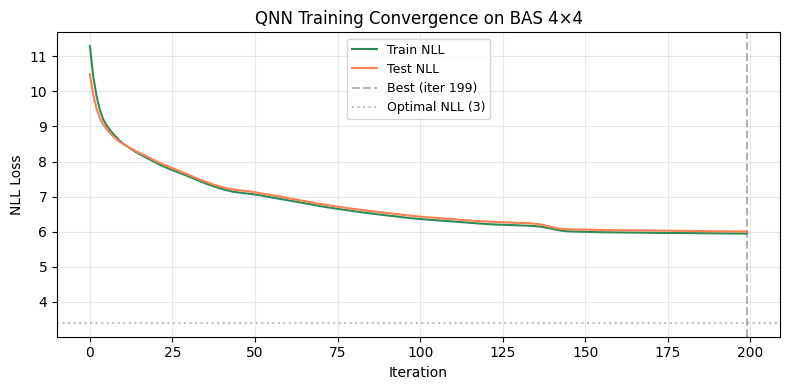

Final train NLL: 5.9464
Final test NLL:  6.0064
Optimal NLL:     3.4012  (perfect uniform over 30 patterns)


In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(result_qnn.loss_history, '-', lw=1.5, color='seagreen', label='Train NLL')
if result_qnn.test_loss_history:
    ax.plot(result_qnn.test_loss_history, '-', lw=1.5, color='coral', label='Test NLL')
    best_iter = int(np.argmin(result_qnn.test_loss_history))
    ax.axvline(best_iter, ls='--', color='gray', alpha=0.6, label=f'Best (iter {best_iter})')

# 理论最优 NLL：均匀 BAS → loss = -sum(w_b * log(1/30)) = N_unique * count_b * log(30)
# 对 deduplicated weights: -sum(count_b * log(1/30)) = N_train * log(30)
optimal_nll = np.log(n_patterns)
ax.axhline(y=optimal_nll, ls=':', color='gray', alpha=0.5, label=f'Optimal NLL ({optimal_nll:.0f})')

ax.set_xlabel('Iteration')
ax.set_ylabel('NLL Loss')
ax.set_title(f'QNN Training Convergence on BAS {ROWS}×{COLS}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train NLL: {result_qnn.loss_history[-1]:.4f}")
if result_qnn.test_loss_history:
    print(f"Final test NLL:  {result_qnn.test_loss_history[-1]:.4f}")
print(f"Optimal NLL:     {optimal_nll:.4f}  (perfect uniform over {n_patterns} patterns)")

## 7) 生成质量定量评估

对比三种方法的 **TVD**、**KL 散度** 和 **BAS fidelity**。

> 由于 $2^{16}$ 种状态的完整分布中非 BAS 状态概率极小，TVD 和 KL 均在完整分布上计算。

In [32]:
def tvd(p, q):
    keys = set(p) | set(q)
    return 0.5 * sum(abs(p.get(k, 0) - q.get(k, 0)) for k in keys)

def kl_div(p, q, eps=1e-10):
    return sum(pv * np.log(pv / (q.get(k, 0) + eps))
              for k, pv in p.items() if pv > 0)

def bas_fidelity(dist, bas_labels):
    return sum(dist.get(l, 0) for l in bas_labels)

methods = ['RBM', 'MADE', 'QNN (NLL)']
dists = [dist_rbm, dist_made, dist_qnn]

print(f"{'Metric':<22}  {'RBM':>10}  {'MADE':>10}  {'QNN':>10}")
print("=" * 58)
print(f"{'TVD vs target':<22}", end="")
for d in dists:
    print(f"  {tvd(dist_target, d):10.4f}", end="")
print()
print(f"{'KL(target||model)':<22}", end="")
for d in dists:
    print(f"  {kl_div(dist_target, d):10.4f}", end="")
print()
print(f"{'BAS fidelity':<22}", end="")
for d in dists:
    print(f"  {bas_fidelity(d, bas_labels):10.2%}", end="")
print(f"  (target: 100.00%)")
print(f"{'Non-BAS leakage':<22}", end="")
for d in dists:
    print(f"  {1 - bas_fidelity(d, bas_labels):10.2%}", end="")
print(f"  (target:   0.00%)")

Metric                         RBM        MADE         QNN
TVD vs target               0.6793      0.0403      0.7139
KL(target||model)           2.1732      0.0044      3.1240
BAS fidelity                98.93%     100.00%      28.61%  (target: 100.00%)
Non-BAS leakage              1.07%       0.00%      71.39%  (target:   0.00%)


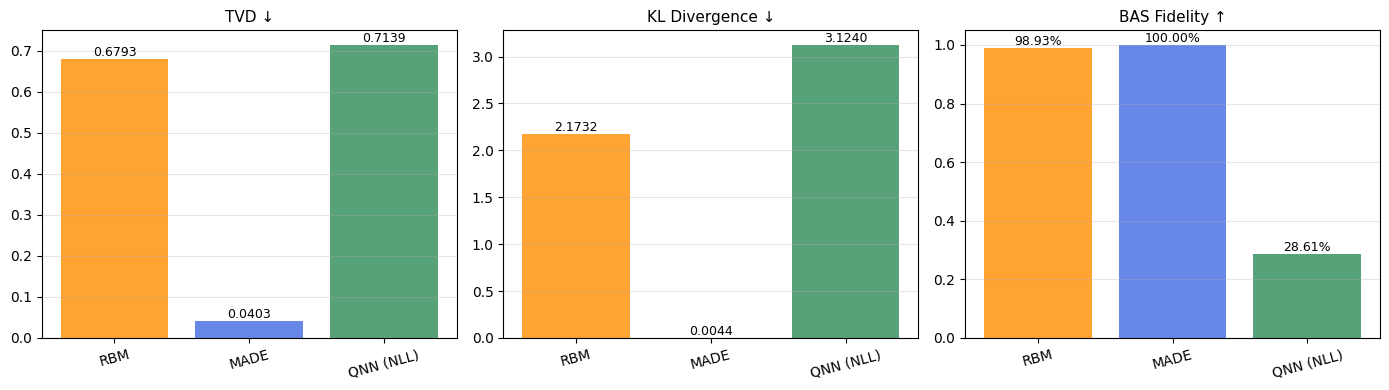

In [33]:
# 可视化对比柱状图
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metric_names = ['TVD ↓', 'KL Divergence ↓', 'BAS Fidelity ↑']
metric_values = [
    [tvd(dist_target, d) for d in dists],
    [kl_div(dist_target, d) for d in dists],
    [bas_fidelity(d, bas_labels) for d in dists],
]
colors = ['darkorange', 'royalblue', 'seagreen']

for ax, metric_name, values in zip(axes, metric_names, metric_values):
    bars = ax.bar(methods, values, color=colors, alpha=0.8)
    ax.set_title(metric_name, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        fmt = f"{val:.2%}" if 'Fidelity' in metric_name else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * max(values),
                fmt, ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8) 生成样本可视化

随机展示 QNN 生成的样本，以 4×4 网格形式呈现。

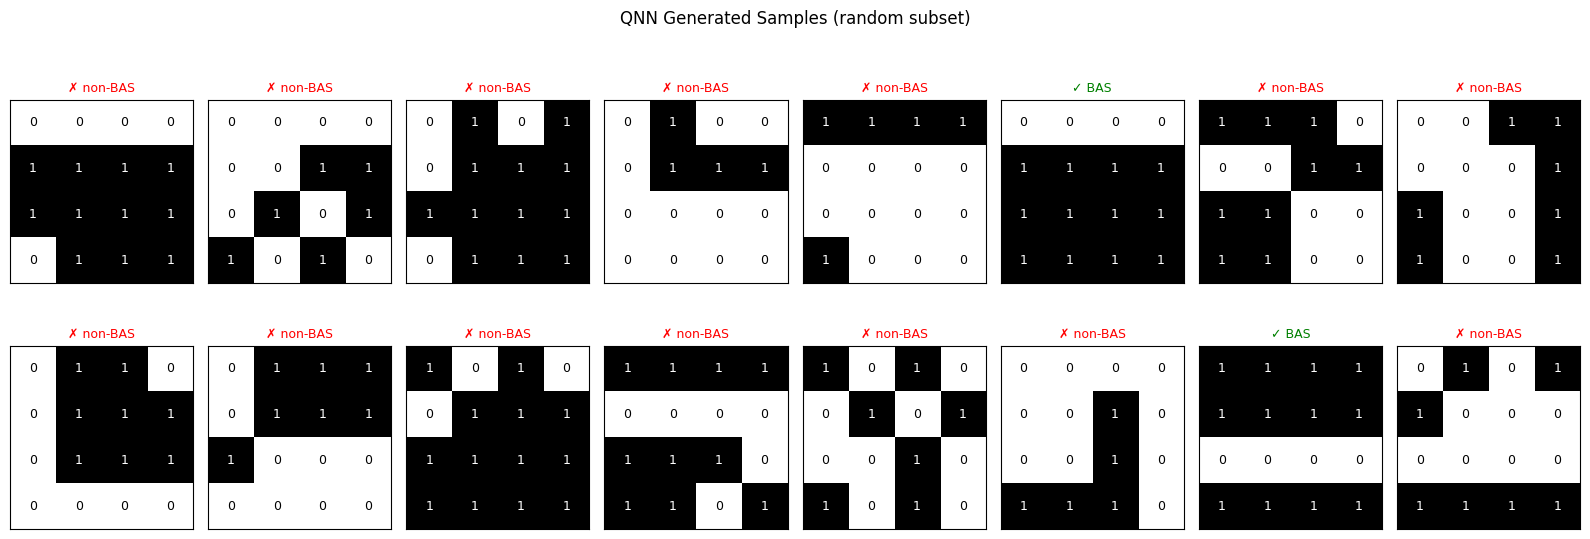

Valid BAS patterns in generated samples: 2344/8192 = 28.6%


In [34]:
gen_samples = np.array(result_qnn.generated_samples, dtype=int)

# 随机选 16 个生成样本展示
show_n = min(16, len(gen_samples))
show_idx = rng.choice(len(gen_samples), size=show_n, replace=False)
show_samples = gen_samples[show_idx]

ncols = 8
nrows = (show_n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat):
    if idx < show_n:
        s = show_samples[idx]
        grid = s.reshape(ROWS, COLS)
        bs = ''.join(str(b) for b in s)
        is_valid = bs in bas_labels
        ax.imshow(grid, cmap='gray_r', vmin=0, vmax=1)
        ax.set_title(f"{'✓ BAS' if is_valid else '✗ non-BAS'}",
                     fontsize=9, color='green' if is_valid else 'red')
        for r in range(ROWS):
            for c in range(COLS):
                ax.text(c, r, str(grid[r, c]), ha='center', va='center',
                        fontsize=9, color='white' if grid[r, c] == 1 else 'black')
    else:
        ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('QNN Generated Samples (random subset)', fontsize=12)
plt.tight_layout()
plt.show()

# 统计有效率
valid_count = sum(1 for s in gen_samples if ''.join(str(b) for b in s) in bas_labels)
print(f"Valid BAS patterns in generated samples: {valid_count}/{len(gen_samples)} = {valid_count/len(gen_samples):.1%}")

## 9) 实验开销分析

In [35]:
n_params = len(result_qnn.best_params)
n_iters = len(result_qnn.loss_history)

rbm_params = sum(p.numel() for p in rbm_model.parameters())
made_params = sum(p.numel() for p in made_model.parameters())
print(f"{'方法':<20} {'参数量':>8} {'训练数据':>10} {'特点'}")
print("=" * 80)
print(f"{'RBM (PCD-10)':<20} {rbm_params:>8} {n_train:>10} {f'{n_hidden} hidden, 能量模型'}")
print(f"{'MADE':<20} {made_params:>8} {n_train:>10} {'自回归, [256,256], Adam'}")
print(f"{'QNN (NLL)':<20} {n_params:>8} {n_train:>10} {f'{num_qubits}q, 4 layers, {n_iters} iters'}")
print(f"\nQNN 模拟设备: {auto_sim_device()}")

方法                        参数量       训练数据 特点
RBM (PCD-10)             1104       5000 64 hidden, 能量模型
MADE                    74256       5000 自回归, [256,256], Adam
QNN (NLL)                 224       5000 16q, 4 layers, 200 iters

QNN 模拟设备: cuda


## 分析与讨论

| 维度 | RBM (PyTorch) | MADE | QNN 量子生成模型 |
|------|:---:|:---:|:---:|
| **模型类型** | 能量模型 | 自回归模型 | 参数化量子线路 |
| **概率空间** | Boltzmann 分布 | 条件概率之积 | Born 分布 $|\langle b\|U(\theta)\|0\rangle|^2$ |
| **训练算法** | PCD-10 | Adam + BCE | Autograd NLL |
| **结构先验** | RBM 二部图 | 自回归掩码 | 量子纠缠 |
| **参数扩展性** | 隐层 × 可见层 | $O(D \cdot H^2)$ | $O(n \cdot L)$ |

**观察**：
- 4×4 BAS 只有 30/65536 = 0.046% 的状态有效，模型需从 $2^{16}$ 维空间中精确锁定结构
- **RBM**（PCD-10）通过持久链维持负相采样，有效学习能量地形中的多模态
- **MADE** 将生成建模转化为序列预测，单次前向传播即可计算精确对数似然
- **QNN** 通过量子纠缠天然编码比特间的相关性，参数量远少于经典模型

**下一步**：
- 增加 QNN 层数或训练迭代观察收敛
- 对比 **参数效率**：QNN 参数 vs RBM/MADE 参数 vs 数据量
- 测试 **非均匀目标分布**（某些 BAS 模式概率更高）
- 在真机上使用 **parameter-shift (MMD)** 路径